# Analiza książek z Wolnych Lektur

Ten notatnik analizuje próbkę tekstów z Wolnych Lektur zapisaną w `data/wolne_lektury_random_sample_25mb.txt`. Celem jest porównanie struktur kombinatorycznych widocznych w słowniku z tym, jak często słowa o takich strukturach faktycznie pojawiają się w literaturze.

## 1. Przygotowanie środowiska

Importujemy biblioteki, parser Wolnych Lektur, loader słownika oraz detektory struktur.

In [13]:
from collections import Counter
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    display = print


def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "natural_languages").is_dir():
            return path
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from natural_languages.data import DataLoader, TextPreprocessor, parse_wolne_lektury_file  # noqa: E402
from natural_languages.detectors import (  # noqa: E402
    AbelianSquareDetector,
    PalindromeDetector,
    ShuffledSquareDetector,
    SquareDetector,
    TangramDetector,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 100)


## 2. Stałe i detektory

Ustawiamy ścieżki do danych, minimalną długość analizowanych słów oraz limit dla kosztownej detekcji przetasowanych kwadratów.

In [2]:
BOOKS_PATH = PROJECT_ROOT / "data" / "wolne_lektury_random_sample_25mb.txt"
DICTIONARY_PATH = PROJECT_ROOT / "data" / "raw" / "pl.txt"

MIN_WORD_LENGTH = 3
MAX_SHUFFLED_LEN = 16
TOP_LIVE_WORDS = 10
MIN_TOKENS_PER_METADATA_GROUP = 5000

STRUCTURES = [
    "square",
    "palindrome",
    "abelian_square",
    "tangram",
    "shuffled_square",
]
STRUCTURE_LABELS = {
    "square": "kwadrat",
    "palindrome": "palindrom",
    "abelian_square": "kwadrat abelowy",
    "tangram": "tangram",
    "shuffled_square": "przetasowany kwadrat",
}

detectors = {
    "square": SquareDetector(),
    "palindrome": PalindromeDetector(),
    "abelian_square": AbelianSquareDetector(),
    "tangram": TangramDetector(),
    "shuffled_square": ShuffledSquareDetector(),
}
preprocessor = TextPreprocessor()


def detect_structure_flags(word: str) -> dict[str, bool]:
    is_square = detectors["square"].check(word)
    is_palindrome = detectors["palindrome"].check(word)
    is_abelian_square = detectors["abelian_square"].check(word)
    is_tangram = detectors["tangram"].check(word)
    is_shuffled_square = (
        is_tangram
        and len(word) <= MAX_SHUFFLED_LEN
        and len(word) % 2 == 0
        and detectors["shuffled_square"].check(word)
    )
    return {
        "square": is_square,
        "palindrome": is_palindrome,
        "abelian_square": is_abelian_square,
        "tangram": is_tangram,
        "shuffled_square": is_shuffled_square,
    }


pd.DataFrame(
    [
        {"parametr": "plik książek", "wartość": str(BOOKS_PATH.relative_to(PROJECT_ROOT))},
        {"parametr": "słownik porównawczy", "wartość": str(DICTIONARY_PATH.relative_to(PROJECT_ROOT))},
        {"parametr": "minimalna długość słowa", "wartość": MIN_WORD_LENGTH},
        {"parametr": "limit przetasowanych kwadratów", "wartość": MAX_SHUFFLED_LEN},
    ]
)

,parametr,wartość
0,plik książek,data/wolne_lektury_random_sample_25mb.txt
1,słownik porównawczy,data/raw/pl.txt
2,minimalna długość słowa,3
3,limit przetasowanych kwadratów,16


## 3. Wczytanie książek

Parser odczytuje metadane każdej książki oraz jej treść. W `books_df` przechowujemy jeden wiersz na jeden tekst.

In [3]:
if not BOOKS_PATH.exists():
    raise FileNotFoundError(f"Brakuje pliku: {BOOKS_PATH}")
if not DICTIONARY_PATH.exists():
    raise FileNotFoundError(f"Brakuje słownika: {DICTIONARY_PATH}")

books = parse_wolne_lektury_file(BOOKS_PATH)
books_df = pd.DataFrame(
    [
        {
            "book_id": index,
            "title": book.title,
            "author": book.author,
            "slug": book.slug,
            "epoch": book.epoch or "brak danych",
            "kind": book.kind or "brak danych",
            "genre": book.genre or "brak danych",
            "text": book.text,
            "characters": len(book.text),
        }
        for index, book in enumerate(books)
    ]
)

books_overview_table_df = books_df.drop(columns=["text"]).head(12)
metadata_counts_table_df = pd.DataFrame(
    [
        {"metryka": "liczba tekstów", "wartość": len(books_df)},
        {"metryka": "liczba autorów", "wartość": books_df["author"].nunique()},
        {"metryka": "liczba epok", "wartość": books_df["epoch"].nunique()},
        {"metryka": "liczba rodzajów", "wartość": books_df["kind"].nunique()},
    ]
)

display(metadata_counts_table_df)
display(books_overview_table_df)

,metryka,wartość
0,liczba tekstów,528
1,liczba autorów,178
2,liczba epok,12
3,liczba rodzajów,3


,book_id,title,author,slug,epoch,kind,genre,characters
0,0,Rękopis znaleziony w Saragossie,Jan Potocki,rekopis-znaleziony-w-saragossie,Romantyzm,Epika,Powieść,1259018
1,1,Wpatrzeni + odbicia wchodzą,Paweł Kozioł,koziol-czarne-kwiaty-dla-wszystkich-wpatrzeniodbicia-wchodza,Współczesność,Liryka,Wiersz,2241
2,2,[Thrènes - Motto],Jan Kochanowski,threnes-motto,Renesans,Liryka,Motto,1643
3,3,dokument 0.18,Maria Cyranowicz,cyranowicz-denpresja-dokument-018,Współczesność,Liryka,Wiersz,2238
4,4,O literaturze rosyjskiej i naszym do niej stosunku dziś i lat temu trzysta,Aleksander Brückner,o-literaturze-rosyjskiej-i-naszym-do-niej-stosunku-dzis-i-lat-temu-trzysta,Pozytywizm,Epika,Rozprawa,98543
5,5,"Buntowniki, czyli stronnictwo-wywrotu",Cyprian Kamil Norwid,norwid-buntowniki-czyli-stronnictwo-wywrotu,Romantyzm,Liryka,Wiersz,2534
6,6,pobocza autostrady,Miłosz Biedrzycki,biedrzycki-pobocza-autostrady,Współczesność,Liryka,Wiersz,2749
7,7,"Śmierć, co trzynaście lat stała koło mnie...",Juliusz Słowacki,smierc-co-trzynascie-lat-stala-kolo-mnie,Romantyzm,Liryka,Wiersz,3117
8,8,Trofea,Krzysztof Kamil Baczyński,baczynski-trofea,Współczesność,Liryka,Poemat,2609
9,9,Małemu wielkiej nadzieje Radziwiłłowi,Jan Kochanowski,fraszki-ksiegi-trzecie-malemu-wielkiej-nadzieje-radziwillowi,Renesans,Liryka,Fraszka,2412


## 4. Tokenizacja i frekwencje

Dla każdej książki normalizujemy słowa, odrzucamy tokeny krótsze niż `MIN_WORD_LENGTH` i zliczamy częstości. `tokens_df` ma jeden wiersz na parę książka-słowo, a nie na każde wystąpienie, dzięki czemu jest mniejszy i wygodniejszy do agregacji.

In [4]:
token_rows = []
for book in books_df.itertuples(index=False):
    normalized_tokens = preprocessor.normalize_words(preprocessor.tokenize(book.text))
    filtered_tokens = [token for token in normalized_tokens if len(token) >= MIN_WORD_LENGTH]
    counts = Counter(filtered_tokens)

    for word, token_count in counts.items():
        token_rows.append(
            {
                "book_id": book.book_id,
                "title": book.title,
                "author": book.author,
                "epoch": book.epoch,
                "kind": book.kind,
                "genre": book.genre,
                "word": word,
                "token_count": token_count,
            }
        )

tokens_df = pd.DataFrame(token_rows)
token_frequency_df = (
    tokens_df.groupby("word", as_index=False)
    .agg(token_count=("token_count", "sum"), book_count=("book_id", "nunique"))
    .assign(length=lambda df: df["word"].str.len())
    .sort_values(["token_count", "word"], ascending=[False, True])
)
book_token_counts_df = tokens_df.groupby("book_id", as_index=False).agg(tokens=("token_count", "sum"))
books_df = books_df.merge(book_token_counts_df, on="book_id", how="left").fillna({"tokens": 0})
books_df["tokens"] = books_df["tokens"].astype(int)

tokenization_summary_table_df = pd.DataFrame(
    [
        {"metryka": "liczba tokenów", "wartość": int(tokens_df["token_count"].sum())},
        {"metryka": "liczba unikalnych słów", "wartość": len(token_frequency_df)},
        {"metryka": "średnio tokenów na tekst", "wartość": round(books_df["tokens"].mean(), 2)},
    ]
)

display(tokenization_summary_table_df)
display(token_frequency_df.head(15))

,metryka,wartość
0,liczba tokenów,2810761.00
1,liczba unikalnych słów,226616.00
2,średnio tokenów na tekst,5323.41


,word,token_count,book_count,length
152122,się,86954,528,3
81923,nie,67321,411,3
46771,jak,17812,528,3
167783,tak,16658,269,3
1246,ale,16100,226,3
48131,jest,15770,528,4
48913,już,11859,242,3
70838,mnie,11660,236,4
47951,jego,10608,157,4
47976,jej,9427,181,3


## 5. Analiza słownika polskiego

Słownik traktujemy jako zbiór typów, czyli różnych słów. Wynik `dictionary_analysis_df` posłuży do porównania z tokenami z książek.

In [5]:
raw_dictionary_words = DataLoader(DICTIONARY_PATH).load_word_list()
dictionary_words = [
    word
    for word in dict.fromkeys(preprocessor.normalize_words(raw_dictionary_words))
    if len(word) >= MIN_WORD_LENGTH
]
dictionary_types_df = pd.DataFrame({"word": dictionary_words, "length": [len(word) for word in dictionary_words]})

dictionary_analysis_rows = []
for word in dictionary_words:
    dictionary_analysis_rows.append({"word": word, "length": len(word), **detect_structure_flags(word)})
dictionary_analysis_df = pd.DataFrame(dictionary_analysis_rows)

dictionary_structure_summary_table_df = pd.DataFrame(
    [
        {
            "struktura": STRUCTURE_LABELS[structure],
            "liczba typów": int(dictionary_analysis_df[structure].sum()),
            "procent typów": round(100.0 * dictionary_analysis_df[structure].mean(), 4),
        }
        for structure in STRUCTURES
    ]
)

display(dictionary_structure_summary_table_df)

,struktura,liczba typów,procent typów
0,kwadrat,65,0.0190
1,palindrom,196,0.0572
2,kwadrat abelowy,87,0.0254
3,tangram,100,0.0292
4,przetasowany kwadrat,73,0.0213


## 6. Analiza unikalnych tokenów z książek

Detektory uruchamiamy na unikalnych tokenach z korpusu, a następnie dokładamy liczbę wystąpień i liczbę książek, w których dane słowo się pojawia.

In [6]:
token_analysis_rows = []
for row in token_frequency_df.itertuples(index=False):
    token_analysis_rows.append(
        {
            "word": row.word,
            "length": row.length,
            "token_count": row.token_count,
            "book_count": row.book_count,
            **detect_structure_flags(row.word),
        }
    )
token_analysis_df = pd.DataFrame(token_analysis_rows)

token_structure_summary_table_df = pd.DataFrame(
    [
        {
            "struktura": STRUCTURE_LABELS[structure],
            "liczba typów w tekstach": int(token_analysis_df[structure].sum()),
            "liczba wystąpień": int(token_analysis_df.loc[token_analysis_df[structure], "token_count"].sum()),
            "procent wystąpień": round(100.0 * token_analysis_df.loc[token_analysis_df[structure], "token_count"].sum() / token_analysis_df["token_count"].sum(), 4),
        }
        for structure in STRUCTURES
    ]
)

display(token_structure_summary_table_df)

,struktura,liczba typów w tekstach,liczba wystąpień,procent wystąpień
0,kwadrat,71,651,0.0232
1,palindrom,118,17246,0.6136
2,kwadrat abelowy,83,1293,0.0460
3,tangram,94,1321,0.0470
4,przetasowany kwadrat,78,675,0.0240


## 7. Types vs Tokens

Porównujemy udział struktur w słowniku z udziałem tych struktur w rzeczywistych wystąpieniach słów w książkach. Dane wejściowe: `types_vs_tokens_plot_df`.

In [7]:
types_vs_tokens_rows = []
total_types = len(dictionary_analysis_df)
total_tokens = int(token_analysis_df["token_count"].sum())

for structure in STRUCTURES:
    type_count = int(dictionary_analysis_df[structure].sum())
    token_count = int(token_analysis_df.loc[token_analysis_df[structure], "token_count"].sum())
    types_vs_tokens_rows.extend(
        [
            {
                "structure": structure,
                "structure_label": STRUCTURE_LABELS[structure],
                "source": "słownik (types)",
                "count": type_count,
                "total": total_types,
                "percent": 100.0 * type_count / total_types if total_types else 0.0,
            },
            {
                "structure": structure,
                "structure_label": STRUCTURE_LABELS[structure],
                "source": "książki (tokens)",
                "count": token_count,
                "total": total_tokens,
                "percent": 100.0 * token_count / total_tokens if total_tokens else 0.0,
            },
        ]
    )
types_vs_tokens_plot_df = pd.DataFrame(types_vs_tokens_rows)

display(types_vs_tokens_plot_df)

,structure,structure_label,source,count,total,percent
0,square,kwadrat,słownik (types),65,342587,0.018973
1,square,kwadrat,książki (tokens),651,2810761,0.023161
2,palindrome,palindrom,słownik (types),196,342587,0.057212
3,palindrome,palindrom,książki (tokens),17246,2810761,0.613570
4,abelian_square,kwadrat abelowy,słownik (types),87,342587,0.025395
5,abelian_square,kwadrat abelowy,książki (tokens),1293,2810761,0.046002
6,tangram,tangram,słownik (types),100,342587,0.029190
7,tangram,tangram,książki (tokens),1321,2810761,0.046998
8,shuffled_square,przetasowany kwadrat,słownik (types),73,342587,0.021308
9,shuffled_square,przetasowany kwadrat,książki (tokens),675,2810761,0.024015


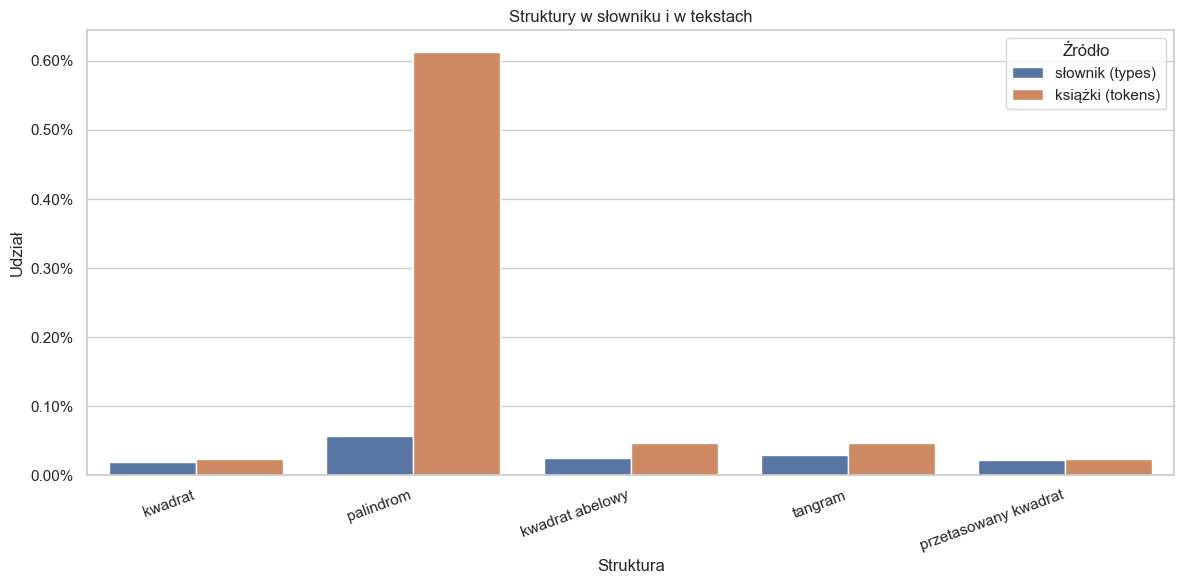

In [8]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=types_vs_tokens_plot_df,
    x="structure_label",
    y="percent",
    hue="source",
)
ax.set_title("Struktury w słowniku i w tekstach")
ax.set_xlabel("Struktura")
ax.set_ylabel("Udział")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.legend(title="Źródło")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 8. Top 10 żywych struktur

Tabela pokazuje najczęściej występujące w książkach słowa spełniające definicje struktur. Filtr długości `MIN_WORD_LENGTH = 3` usuwa najkrótsze, mało informacyjne przypadki. Dane wejściowe: `live_structures_table_df`.

In [9]:
live_structure_rows = []
for structure in STRUCTURES:
    top_words = token_analysis_df[token_analysis_df[structure]].sort_values(
        ["token_count", "book_count", "word"], ascending=[False, False, True]
    ).head(TOP_LIVE_WORDS)
    for rank, row in enumerate(top_words.itertuples(index=False), start=1):
        live_structure_rows.append(
            {
                "struktura": STRUCTURE_LABELS[structure],
                "miejsce": rank,
                "słowo": row.word,
                "długość": row.length,
                "liczba użyć": row.token_count,
                "liczba książek": row.book_count,
            }
        )
live_structures_table_df = pd.DataFrame(live_structure_rows)

display(live_structures_table_df)

,struktura,miejsce,słowo,długość,liczba użyć,liczba książek
0,kwadrat,1,mama,4,201,30
1,kwadrat,2,toto,4,143,5
2,kwadrat,3,baba,4,94,31
3,kwadrat,4,jaja,4,38,16
4,kwadrat,5,lala,4,17,6
5,kwadrat,6,tata,4,14,6
6,kwadrat,7,kuku,4,12,4
7,kwadrat,8,niania,6,10,6
8,kwadrat,9,papa,4,8,4
9,kwadrat,10,mrumru,6,5,3


## 9. Gęstość struktur według metadanych

Łączymy wyniki detekcji z częstościami słów w konkretnych książkach. Gęstość liczymy jako liczbę wystąpień słów danej struktury na 10 000 tokenów w grupie metadanych.

In [10]:
token_structure_by_book_df = tokens_df.merge(
    token_analysis_df[["word", *STRUCTURES]],
    on="word",
    how="left",
)


density_columns = [
    "group_type",
    "group_value",
    "structure",
    "structure_label",
    "structure_tokens",
    "total_tokens",
    "density_per_10000",
]


def build_density_df(group_column: str, group_label: str) -> pd.DataFrame:
    rows = []
    for group_value, group_df in token_structure_by_book_df.groupby(group_column):
        total_tokens_in_group = int(group_df["token_count"].sum())
        if total_tokens_in_group < MIN_TOKENS_PER_METADATA_GROUP:
            continue
        for structure in STRUCTURES:
            structure_tokens = int(group_df.loc[group_df[structure], "token_count"].sum())
            rows.append(
                {
                    "group_type": group_label,
                    "group_value": group_value,
                    "structure": structure,
                    "structure_label": STRUCTURE_LABELS[structure],
                    "structure_tokens": structure_tokens,
                    "total_tokens": total_tokens_in_group,
                    "density_per_10000": 10000.0 * structure_tokens / total_tokens_in_group if total_tokens_in_group else 0.0,
                }
            )
    return pd.DataFrame(rows, columns=density_columns)


kind_density_plot_df = build_density_df("kind", "rodzaj literacki")
epoch_density_plot_df = build_density_df("epoch", "epoka")
if epoch_density_plot_df.empty:
    epoch_density_heatmap_df = pd.DataFrame(columns=[STRUCTURE_LABELS[structure] for structure in STRUCTURES])
else:
    epoch_order = (
        epoch_density_plot_df[["group_value", "total_tokens"]]
        .drop_duplicates()
        .sort_values("total_tokens", ascending=False)["group_value"]
        .tolist()
    )
    epoch_density_heatmap_df = (
        epoch_density_plot_df.pivot_table(
            index="group_value",
            columns="structure_label",
            values="density_per_10000",
            aggfunc="sum",
            fill_value=0.0,
        )
        .reindex(index=epoch_order, columns=[STRUCTURE_LABELS[structure] for structure in STRUCTURES])
        .fillna(0.0)
    )

pd.DataFrame(
    [
        {"DataFrame": "kind_density_plot_df", "wiersze": len(kind_density_plot_df)},
        {"DataFrame": "epoch_density_plot_df", "wiersze": len(epoch_density_plot_df)},
        {"DataFrame": "epoch_density_heatmap_df", "wiersze": len(epoch_density_heatmap_df)},
    ]
)

,DataFrame,wiersze
0,kind_density_plot_df,15
1,epoch_density_plot_df,50
2,epoch_density_heatmap_df,10


## 10. Gęstość struktur według rodzaju literackiego

Wykres porównuje epikę, lirykę i dramat. Wartości są znormalizowane do 10 000 tokenów, więc można porównywać grupy o różnej długości. Dane wejściowe: `kind_density_plot_df`.

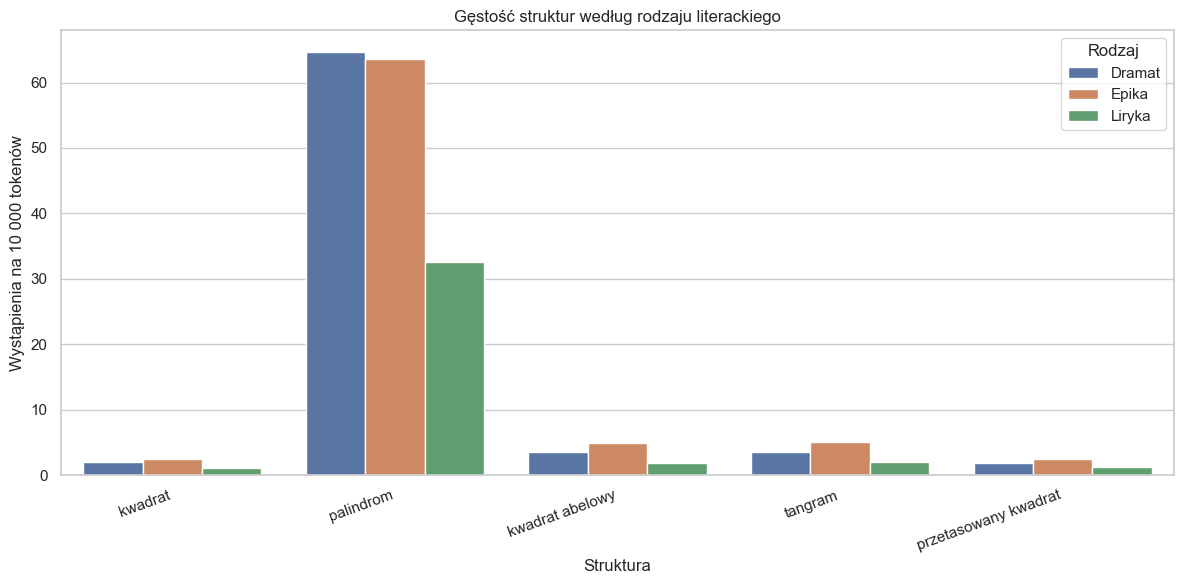

In [11]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=kind_density_plot_df,
    x="structure_label",
    y="density_per_10000",
    hue="group_value",
)
ax.set_title("Gęstość struktur według rodzaju literackiego")
ax.set_xlabel("Struktura")
ax.set_ylabel("Wystąpienia na 10 000 tokenów")
ax.legend(title="Rodzaj")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 11. Heatmapa epoka × struktura

Heatmapa pokazuje, jak zmienia się gęstość struktur między epokami. Grupy z bardzo małą liczbą tokenów są pomijane przez próg `MIN_TOKENS_PER_METADATA_GROUP`. Dane wejściowe: `epoch_density_heatmap_df`.

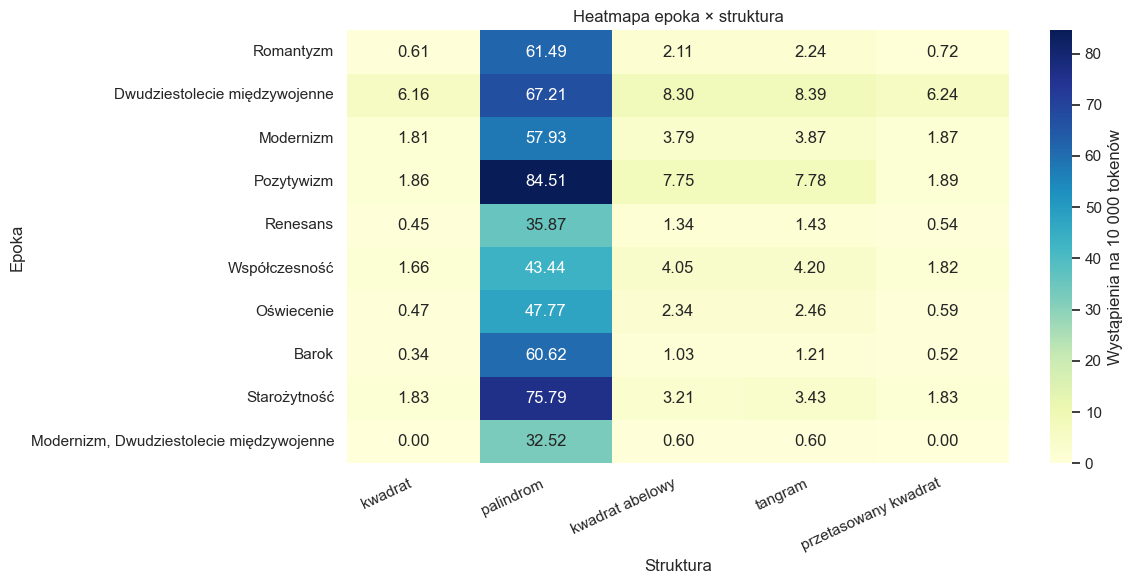

In [12]:
plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    epoch_density_heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Wystąpienia na 10 000 tokenów"},
)
ax.set_title("Heatmapa epoka × struktura")
ax.set_xlabel("Struktura")
ax.set_ylabel("Epoka")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Podsumowanie

Notebook rozdziela analizę słownikową (`types`) od analizy frekwencyjnej (`tokens`). Dzięki temu można zobaczyć, czy struktury kombinatoryczne są tylko rzadkimi hasłami słownikowymi, czy rzeczywiście pojawiają się w użyciu literackim. Sekcja metadanych pozwala dodatkowo porównać rodzaje literackie i epoki na wspólnej skali: liczbie wystąpień na 10 000 tokenów.